# Player Valuation and Squad Spending: What Really Predicts Success in the Premier League?

## Introduction

The Premier League is widely regarded as one of, if not the, best and most competitive leagues in world football.  With clubs now spending hundreds of millions of pounds each season, what actually determines the transfer value of players and does this spending actually lead to better performance in the league?

This blog uses data from the 2022/23, 2023/24, and 2024/25 Premier League seasons to try and answer these questions.

## The Data

Two different datasets are combined for analysis in this blog.

Player performance data was collected from Understat (https://understat.com) using the soccerdata python library. Understat tracks many insightful metrics for all players across the top leagues including but not limited to: Expected Goals (xG), Expected assists (xA), and non penalty Expected Goals (npxG), but for this project, they were specifically filtered for just the Premier League. These metrics are particularly useful because they help measure the quality of chances rather than just pure output.

Transfer market valuations were sourced from the Transfermarkt-dataset.zip (https://github.com/dcaribou/transfermarkt-datasets) published openly on GitHub by David Cariboo, who scrapes and maintains the data from Transfermarkt.com, the most widely used platform for player valuations in football.

Merging the data came to be a rather tedious task. Both sources used different naming for both players and clubs, and loan players faced issues with appearing at different clubs across the two datasets. After cleaning, normalising player names, and handling the loan transfers, the final polished dataset covered 1294 players across 20 Premier League clubs and three seasons, with zero missing values.

## The Transfer Market in Numbers

Before determining what factors drive transfer value, it's important to understand the data first.

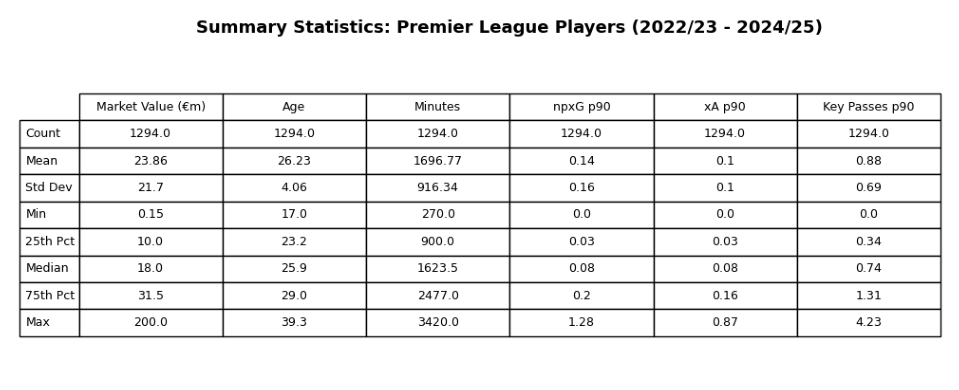

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
 
players = pd.read_csv("data/clean/players.csv")
squads  = pd.read_csv("data/clean/squads.csv")
 
img = mpimg.imread("figures/fig1_summary_statistics.png")
plt.figure(figsize=(14, 4))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

One key thing to note is the gap between the mean and the median market value, €23.86m and €18.0m respectively. This means that the data is right skewed which can be explained by a small number of elite, premium players who distort the distribution. This would be players such as Erling Haaland and Bukayo Saka, who have respective market values of €200m and €150m. This type of skew can similarly be seen in labour markets, where a winner takes all dynamic takes place.

The distribution of age is also very interesting. The mean age in the dataset is 26.3 years old whilst the oldest player is 39.3 years old. This will be explored in greater depth later, where it will be discovered that age is one of the most powerful drivers of market value.

## What Factors Actually Drive Player Market Value?

Before building a regression, it's useful to first look how different metrics correlate with market value.

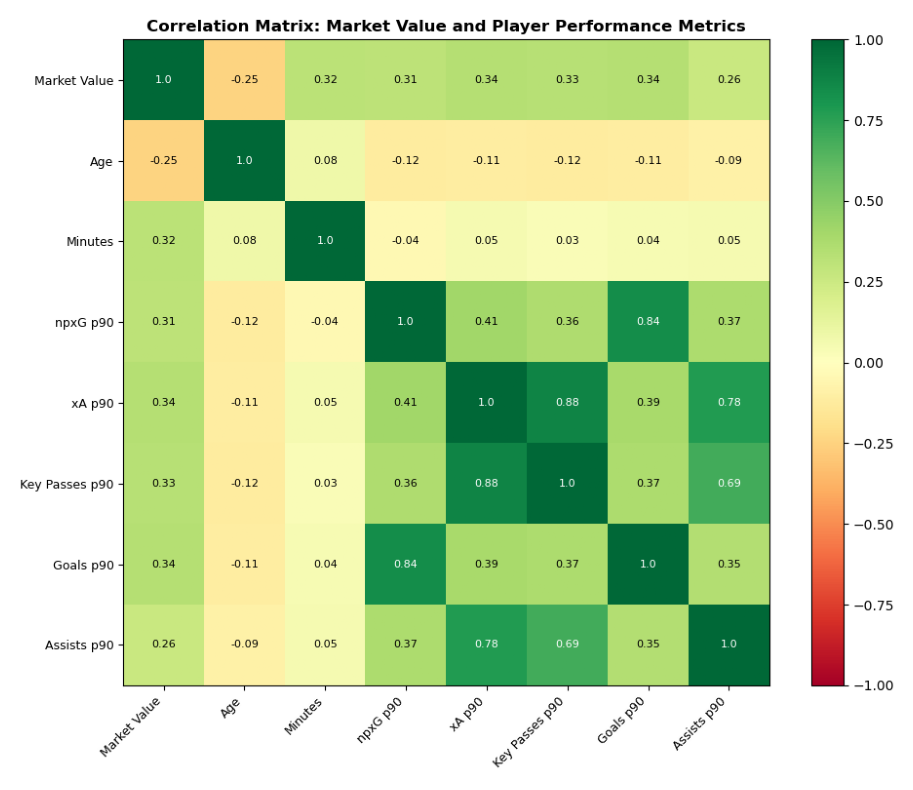

In [2]:
img = mpimg.imread("figures/fig2_correlation_heatmap.png")
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

This heatmap displays a few important themes. Market value has a negative correlation with age (-0.25) which means that older players are worth less compared to if they were younger, despite output. Market Value also strongly correlates with Minutes 
played (0.32) which is understandable, as better players will tend to play more frequently. Similarly, Expected Assists p90 (0.34) and Non-penalty Expected Goals p90 (0.31) are positively correlated, highlighting the value of chance creation and getting into good positions to convert chances into goals.

The heatmap also shows a strong correlation between Key Passes p90 and Expected Assists p90, which is expected as these two are very similar statistics. Hence, when building the regression, it's best to keep this in mind as including both can lead to multicollinearity which we ideally want to avoid. Note that p90 stats are used so players can be compared.

To build our model, we'll use an Ordinary Least Squares (OLS) Regression to test which metrics independently predict market value whilst controlling other variables.

## Building a Model to Understand the Drivers of Player Market Value

The regression models Log Market Value as a function of npxG p90, xA p90, age, age squared, and position. Goalkeepers are excluded due to their value being determined by completely different metrics, such as save percentage and goals prevented. Forwards act as the reference position.

Log Market Value is used to account for the right skew of the data by helping make the distribution approximately normal. Furthermore, key passes p90 is left out because of the high level of multicollinearity with xA p90 previously mentioned.

The following table displays the coefficients of each significant factor from the regression

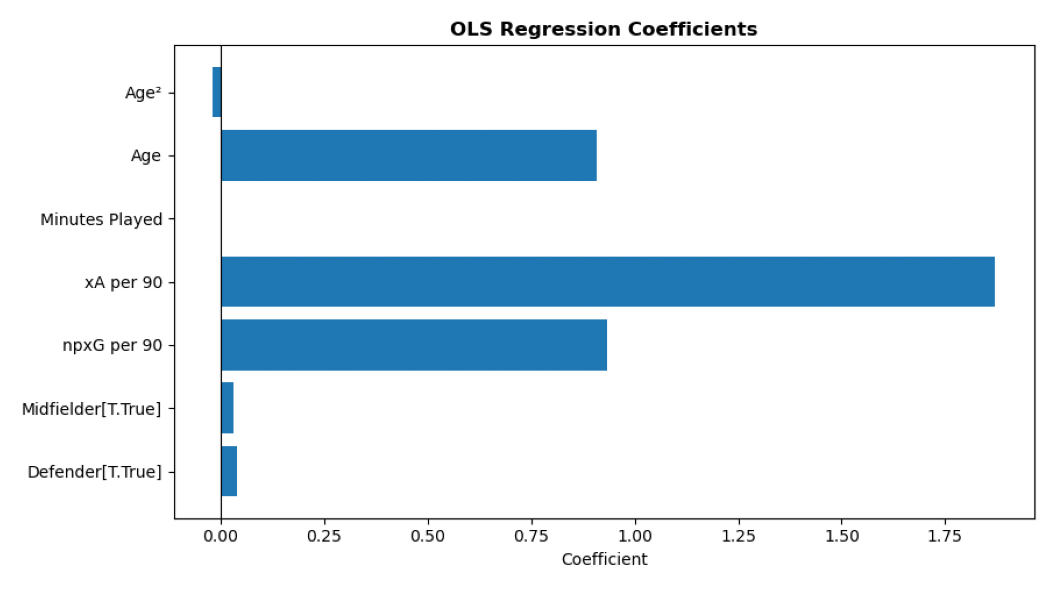

In [3]:
img = mpimg.imread("figures/fig3_coefficients.png")
plt.figure(figsize=(11, 6))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

The model explains 45% of the variation in player market value with a R^2 value of 0.454. From only age and on pitch statistics, this is promising given the unpredictability of football with external factors such as marketability and injuries which also influence valuations.

Four variables are statistically significant at the 5% level as shown by the figure:

- xA p90 has the largest coefficient amongst the metrics at 1.87, which means players with 1 unit higher xA p90 are roughly valued 6.5 times more, holding everything else constant. This highlights the importance of chance creation in modern football.

- npxG p90 has a coefficient of 0.93, showing that it remains important that players get themselves into positions and situations to score goals.

- Minutes Played is also significant, despite the small coefficient of 0.0004 causing a virtually invisible bar. This means clubs pay a very small premium for players who can stay fit and perform consistently throughout the season.

- Age and Age^2 are both significant with respective coefficients of 0.91 and -0.02. This tells us that market value increases with a player's age up until a peak, and then declines. The data implies this peak age is 24.3 years and every year after is associated with a decrease in market value even if output remains strong.

The position dummies on the figure are statistically insignificant. This shows that the market values actual output and performance rather than specific positions, which can potentially be explained by modern tactics requiring players to increasingly play in various different positions and roles throughout the duration of a game.

## Inaccuracies in the Model: Why Are Players Being Mispriced?

With the model capturing how players should be valued based on their performance and age, the residuals (gap between predicted and actual values) uncovers where the market is mispricing players.

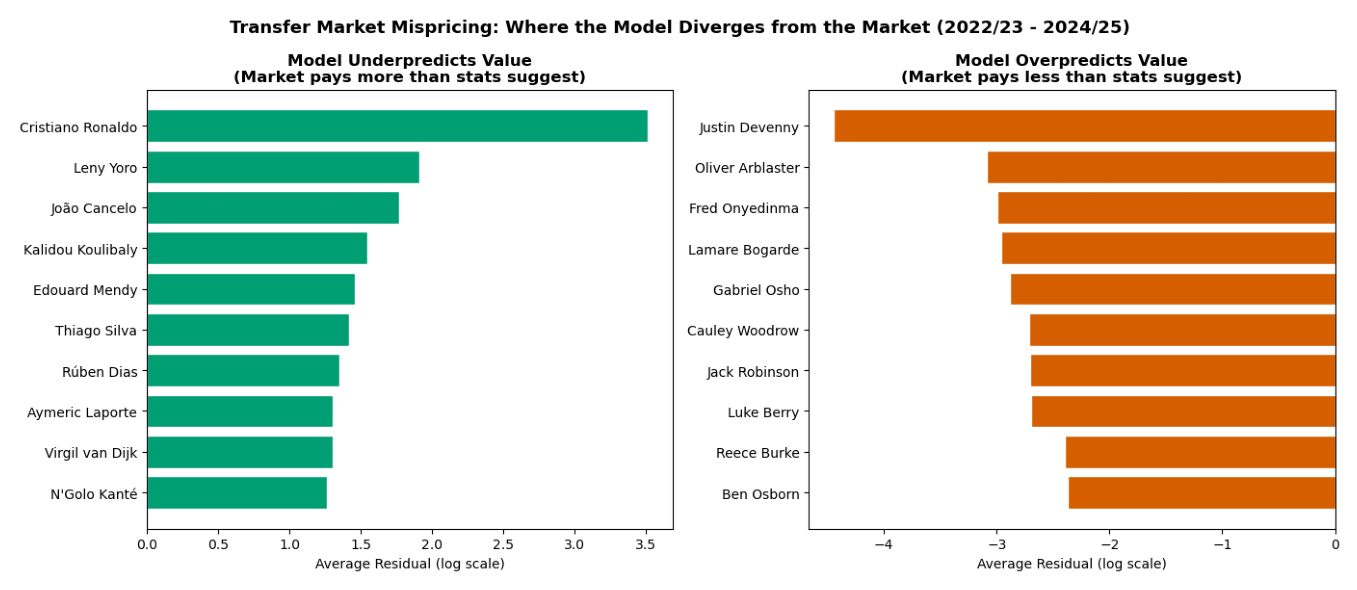

In [4]:
img = mpimg.imread("figures/fig4_over_undervalued.png")
plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

The most overvalued player according to our model is Cristiano Ronaldo, whose average residual was significantly the largest. This isn't necessarily because his performance metrics were amazing, as his npxG p90 wasn't out of this world, but rather because the model's age penalty is so strong that it predicted a 37 year old to be worth almost nothing, whilst Transfermarkt valued him at €20m. However, from a non-data standpoint and in a footballing context, this valuation makes sense as Ronaldo is widely regarded as one of the greatest players of all time who could still perform at a high enough level despite his age, whilst offering great marketability. Ronaldo is truely an anomaly who highlights the limitation of the model to not account for non-footballing factors.

Leny Yoro however appears for a completely different reason. Due to him being a recent transfer to Manchester United from Ligue 1 (The French 1st Division), his statistics do not include his performance in France, meaning his stats come from a much smaller sample due to his limited Premier League minutes. This highlights another limitation of the model when it comes to new transfers coming from different leagues.

The rest of the players on the chart are undervalued for a similar reason to Ronaldo, being overpenalised for old age despite being able to perform at a high level and having strong marketability; just not to the same extent of Ronaldo himself.

On the other side of the spectrum, young players such Justin Devenny and Oliver Arblaster have lower market values despite decent p90 metrics. What the model doesn't sufficiently account for is that these players have limited minutes played; it sees their p90 stats as impressive and predicts accordingly. However in reality, the actual market draws from scouting reports and broader context that helps to give it more accurate valuations.

The 270 minute minimum threshold in the data cleaning does slightly help alleviate this problem, but it does not completely eliminate it.

## Does Money Buy Success?

Having now looked at what drives individual player's market values, the next question is whether a club's total squad value corresponds to its final league position?

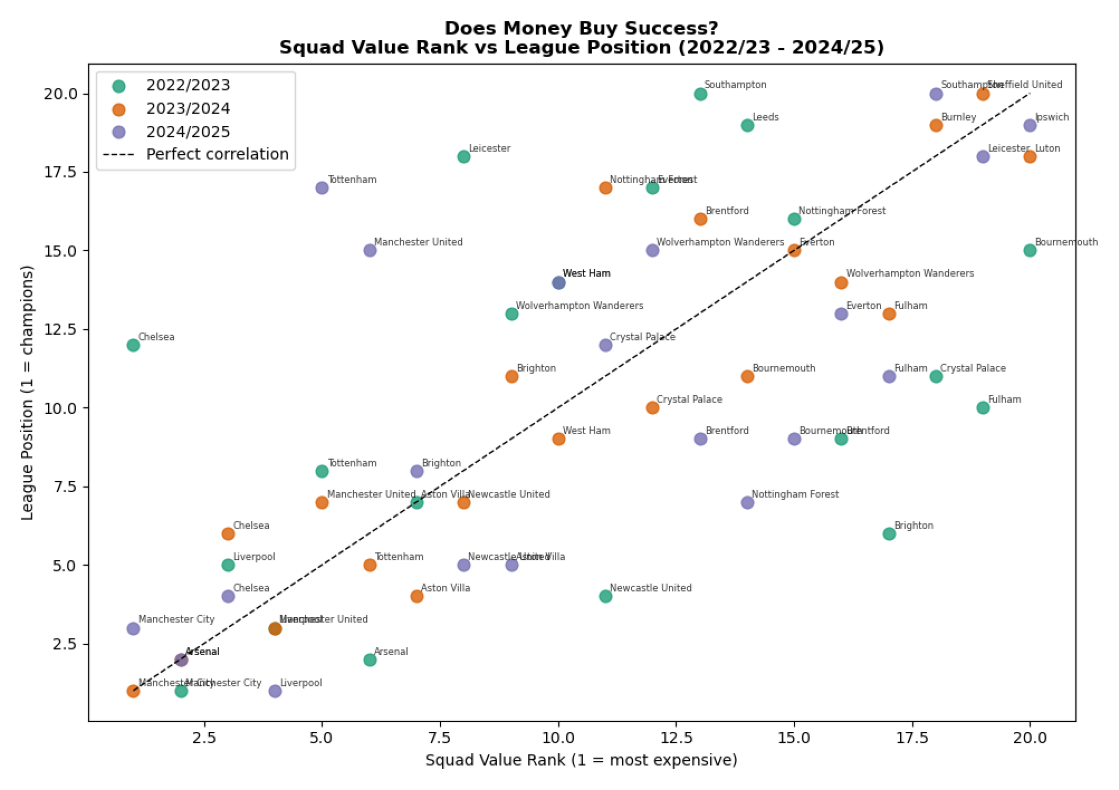

In [5]:
img = mpimg.imread("figures/fig5_rank_comparison.png")
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

The scatter plot shows how Squad Value Ranks and Final League Position differs for each club across the 3 seasons. If money perfectly predicted success, each club would sit on the dashed line but it can be seen that this clearly isn't the case.

Whilst richer clubs do tend to have stronger finishes, as can be seen by the likes of Arsenal, Manchester City, and Liverpool being consistently in the bottom left area, the relationship is far from perfect and reality is much more nuanced.

Bournemouth has consistently punched above its financial weight, finishing above their Squad Value Rank in all 3 seasons. This can be explained by smart recruitment in the form of their manager Andoni Iraola who has consistently been praised for his tactics, and also in the form of the players they sign, who outperform their market value.

Something similar can be said about Brighton, whose 2022/23 6th place finish, despite a very low squad value, reflects the effectiveness of owner Tony Bloom's moneyball-like transfer strategy.

Chelsea on the other hand, finished 12th in the same season whilst having the 3rd most expensive squad, which can be explained by their ineffective transfer strategy, heavily investing into future potential following the takeover of new owners BlueCo.

At the other side of the table, newly promoted clubs such as Burnley, Sheffield United, Luton and Ipswich can be seen in the top right. This shows the difficulties that newly promoted clubs when trying to remain in the Premier League, highlighting its competitiveness and the difference in level to the Championship

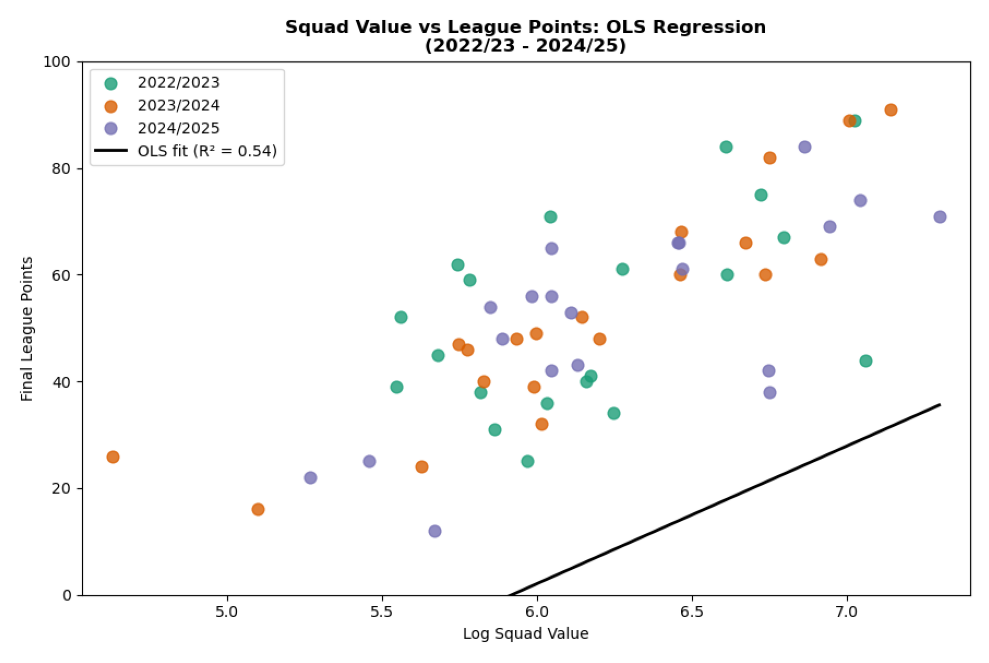

In [6]:
img = mpimg.imread("figures/fig6_squad_regression.png")
plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

The OLS regression using Log Squad Value and Average Squad Age confirms this pattern. With an R^2 value of 0.54, the model explains 54% of the variation in Final League Points. The coefficient of Log Squad Value is 25.75 and statistically significant, which means that doubling squad value roughly equates to an extra 18 points in the leagues or 6 wins.

Average Squad Age (1.7136) however was not statistically significant with a p value of 0.27. This means younger squads do not outperform their spending and again, the example of Chelsea in 2022/23 can be used where they recklessly focused a lot of investment into younger players with high potential.

It is worth noting however that OLS assumes the outcome can take any value, including negative points, which is impossible in football unless a club breaches rules such as financial fair play and is given a points deduction.

## Conclusion

This blog aimed to answer two questions: 

1) What Factors Drive Player Market Values?

2) Does Money Buy Success?

To answer the first question, the data shows that xA is significantly rewarded by the market whilst position hardly matters when performance is accounted for. One of the more interesting discoveries was the peak age of 24.3 for market value. The age penalty can create inaccurate predictions for players who still perform at a high level despite old age. On the contrary, younger players with less Premier League experience can be overvalued by the model compared to their actual market value due limited evidence and inflated p90 statistics.

For the second question "Does Money Buy Success?", the answer is generally yes. Squad value explains more than half the variation in total league points across three seasons, and the richest clubs almost always finish near the top of the table. However clubs like Bournemouth, Nottingham Forest, and Brighton, show the impact that smart recruitment and management can have; clubs like Chelsea act as a cautionary tale for irresponsible hyperopic transfer strategy.

Now whilst the data and conclusions that came from the analysis are interesting, it can be argued that what the data misses out is just as interesting, if not more. Factors such as commercial appeal, marketability, and future potential don't show up in statistics, but they have a significant impact on market valuations. Deep in the gaps between the predicted values from the model, and actual transfer values from Transfermarkt, lie iconic players like Cristiano Ronaldo, who some argue has achieved GOAT (Greatest of All Time) status. Given his performance is so out of reach of the model, it really is hard to argue otherwise.

At the end of the day, football is just like economics: the market is right most of the time, just not always.